# Source of data
link - https://www.kaggle.com/datasets/debayank2024/house-price-prediction

About Dataset

Understanding housing markets is a classic challenge in data science and machine learning. This dataset contains 4,600 historical property sales records, primarily focused on the Washington State real estate market (including Seattle, Bellevue, Redmond, and surrounding areas). It provides a comprehensive overview of how structural, historical, and geographic features impact property valuation
Target To analyse data and predict

In [1]:
# Importing important libraries 
import pandas as pd
import numpy as np 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('modified_data.csv')
print(df.head())

         date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1  2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2  2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3  2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4  2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370            280      1921   
2           0     0          4        1930              0      1966   
3           0     0          4        1000           1000      1963   
4           0     0          4        1140            800      1976   

   yr_renovated                    street       city  statezip  price_per_sqft  
0          








# INFORMATION 
Dataset Information
Prices: House prices determined by overall property condition, features, and level of luxury.
Property Features: Count of bedrooms, bathrooms, and floors, along with living area and basement square footage.
Condition: Overall property condition rating on a scale of 1 to 5.
Timeline: Year the property was originally built and the year of its most recent renovation.
Location & Lot Size: Geographic address details (street, city, state, zip) and total lot size.


# CHECKING ERRORS

In [3]:
# We will check the data if it have any errors or not by using info function and statatics

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

# ERRORS LIST BY INFO
Date column have data type as string
bedrooms ,floor and bathrooms are in float instead of int
There are no NaN(empty inputs)

In [5]:
# cleaning data types error 
df['date'] = pd.to_datetime(df['date'] , errors = 'coerce')
df['bedrooms'] = df['bedrooms'].astype('int')
df['bathrooms'] = df['bathrooms'].astype('int')
df['floors'] = df['floors'].astype('int')
print(df['price'].isnull().sum())
df['price'] = df['price'].dropna()
print(df['price'].isnull().sum())
# Option A: Filter directly using boolean indexing (best practice)
df = df[(df['sqft_living'] > 500) & (df['sqft_living'] < 4500)]

# Option B: Set values to NaN first, then dropna on the whole DataFrame
df['sqft_living'] = df['sqft_living'].where((df['sqft_living'] > 500) & (df['sqft_living'] < 4500))
df = df.dropna()
# Filter out invalid sqft values directly from the DataFrame
df = df[(df['sqft_living'] > 500) & (df['sqft_living'] < 4500)]
df = df[(df['sqft_lot'] > 1000) & (df['sqft_lot'] < 50000)]
print(df[    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        "waterfront",
        "view",
        "condition",
        "sqft_basement"
    ]].isnull().sum())
print('cleaning completed !!!!!')

0
0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_basement    0
dtype: int64
cleaning completed !!!!!


In [6]:
# statatics
print(df.describe().round(1)) # using round because price is in scientific notations

                             date       price  bedrooms  bathrooms  \
count                        4290      4290.0    4290.0     4290.0   
mean   2014-06-07 05:40:01.678321    529511.1       3.4        1.7   
min           2014-05-02 00:00:00         0.0       0.0        0.0   
25%           2014-05-21 00:00:00    317000.0       3.0        1.0   
50%           2014-06-09 00:00:00    453000.0       3.0        2.0   
75%           2014-06-24 00:00:00    640000.0       4.0        2.0   
max           2014-07-10 00:00:00  26590000.0       9.0        5.0   
std                           NaN    536952.4       0.9        0.7   

       sqft_living  sqft_lot  floors  waterfront    view  condition  \
count       4290.0    4290.0  4290.0      4290.0  4290.0     4290.0   
mean        2054.7    9395.7     1.4         0.0     0.2        3.5   
min          520.0    1002.0     1.0         0.0     0.0        1.0   
25%         1450.0    5000.0     1.0         0.0     0.0        3.0   
50%         19

* Summary Statistics (Mean, Min, Max)
* price: Mean = 551,963.0 | Min = 0.0 | Max = 26,590,000.0
* bedrooms: Mean = 3.4 | Min = 0.0 | Max = 9.0
* bathrooms: Mean = 1.8 | Min = 0.0 | Max = 8.0
*  sqft_living: Mean = 2,139.3 | Min = 370.0 | Max = 13,540.0
* sqft_lot: Mean = 14,852.5 | Min = 638.0 | Max = 1,074,218.0
* floors: Mean = 1.5 | Min = 1.0 | Max = 3.0
* waterfront: Mean = 0.0 | Min = 0.0 | Max = 1.0
* view: Mean = 0.2 | Min = 0.0 | Max = 4.0
* condition: Mean = 3.5 | Min = 1.0 | Max = 5.0
* sqft_above: Mean = 1,827.3 | Min = 370.0 | Max = 9,410.0
* sqft_basement: Mean = 312.1 | Min = 0.0 | Max = 4,820.0
* yr_built: Mean = 1970.8 | Min = 1900.0 | Max = 2014.0
* yr_renovated: Mean = 808.6 | Min = 0.0 | Max = 2014.0
* price_per_sqft: Mean = 265.9 | Min = 0.0 | Max = 22,533.9

In [7]:
# Now we will check key points of data using sql

# SQL KEY POINTS

In [8]:
# first we will connect sql with data
conn = sqlite3.connect('house.db')
df.to_sql('house_data',conn,index = False , if_exists = 'replace')

4290

In [9]:
# format - each query will answer a question for analysis

# Question 1- Cities with the highest prices of house ?
query1 = 'SELECT "city" , AVG("price") as avg_price FROM house_data GROUP BY city ORDER BY avg_price DESC LIMIT 3'
print(pd.read_sql_query(query1,conn).round(2))

# Question 2 - Rank cities with the highest price per square feet area
query2 = 'SELECT "city" , AVG("price_per_sqft") as avg_sqrft FROM house_data GROUP BY city ORDER BY avg_sqrft DESC LIMIT 3 '
print(pd.read_sql_query(query2,conn))

# Question 3- Cities with the lowest prices of house ?
query3 = 'SELECT "city" , AVG("price") as avg_price FROM house_data GROUP BY city ORDER BY avg_price ASC LIMIT 3'
print(pd.read_sql_query(query3,conn).round(2))

# Question 4 - Rank cities with the lowest price per square feet area
query4 = 'SELECT "city" , AVG("price_per_sqft") as avg_sqrft FROM house_data GROUP BY city ORDER BY avg_sqrft ASC LIMIT 3 '
print(pd.read_sql_query(query4,conn))

# Question 5 - City with the average highest condition of houses
query5 = 'SELECT "city" , AVG("condition") as avg_condt FROM house_data GROUP BY city ORDER BY avg_condt LIMIT 3 '
print(pd.read_sql_query(query5,conn).round(2))

           city   avg_price
0        Medina  1816016.67
1  Yarrow Point  1194837.50
2    Clyde Hill  1074140.00
                 city  avg_sqrft
0  Beaux Arts Village   500.0000
1        Yarrow Point   490.3825
2              Medina   485.2000
        city  avg_price
0  Skykomish  134000.00
1     Algona  207288.00
2    Pacific  225233.33
          city   avg_sqrft
0       Algona  129.128000
1    Skykomish  136.730000
2  Federal Way  144.895944
              city  avg_condt
0        Skykomish       3.00
1  Snoqualmie Pass       3.00
2           Duvall       3.03


# VERDICT BY SQL
* Most expensive city with the highest average price of houses : Medina - 20,46,559
* Most expensive city with highest average square ft area price : Beaux arts village - 500 per sqft
* Least expensive city with lowest average price of houses : Algona - 2,07,288
* Least expensive city with lowest average square ft area price : Algona - 129 per sqft
* city with best condition of houses : Snoqualmie Pass 3.00 , Snoqualmie 3.02 , Tukwila 3.03

# PANDAS

In [10]:
# top 3 city with the most houses
most_house = df['city'].value_counts()
print(most_house.head(3))
print(most_house.tail(3))

most_years = df['yr_built'].value_counts()
print(most_years.head(3))
print(most_years.tail(3))


city
Seattle     1515
Renton       278
Bellevue     264
Name: count, dtype: int64
city
Snoqualmie Pass       1
Beaux Arts Village    1
Preston               1
Name: count, dtype: int64
yr_built
2006    97
2005    91
1978    83
Name: count, dtype: int64
yr_built
1933    4
1934    4
1936    3
Name: count, dtype: int64


## Pandas Verdict
* **Cities with most houses** : Seattle     1573 , Renton       293 , Bellevue     286
* **Cities with the lowest number houses** : inglewood-Finn Hill  , snoqualmie Pass , Beaux arts village all have 1 hoses only
* **Years with most and least built houses** : 2006 - 111 and 1936 - 3
* The "Beaux arts village" have only one house but it has highest price of house

# PLOTTING

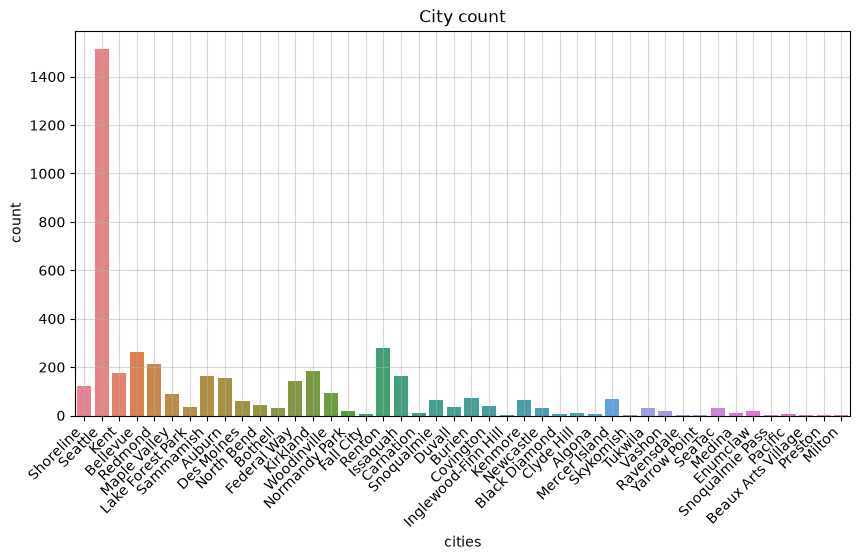

In [11]:
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'city', hue = 'city')
plt.title('City count')
plt.xlabel('cities')
plt.ylabel('count')
plt.grid(True,alpha = 0.5)
plt.xticks(rotation = 45 , ha = 'right' )
plt.show()

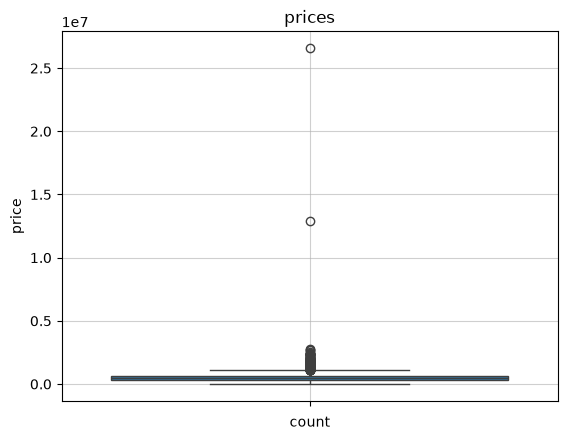

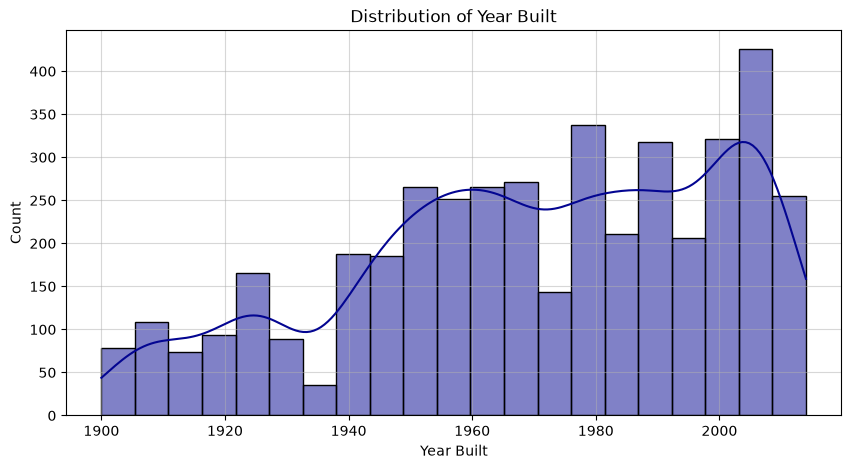

In [12]:
sns.boxplot(data = df , y = 'price')
plt.title('prices')
plt.ylabel('price')
plt.xlabel('count')
plt.grid(True,alpha = 0.6)
plt.show

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='yr_built', kde=True,color = '#030591')
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')
plt.grid(True, alpha=0.5)
plt.show()

# CORRELATION

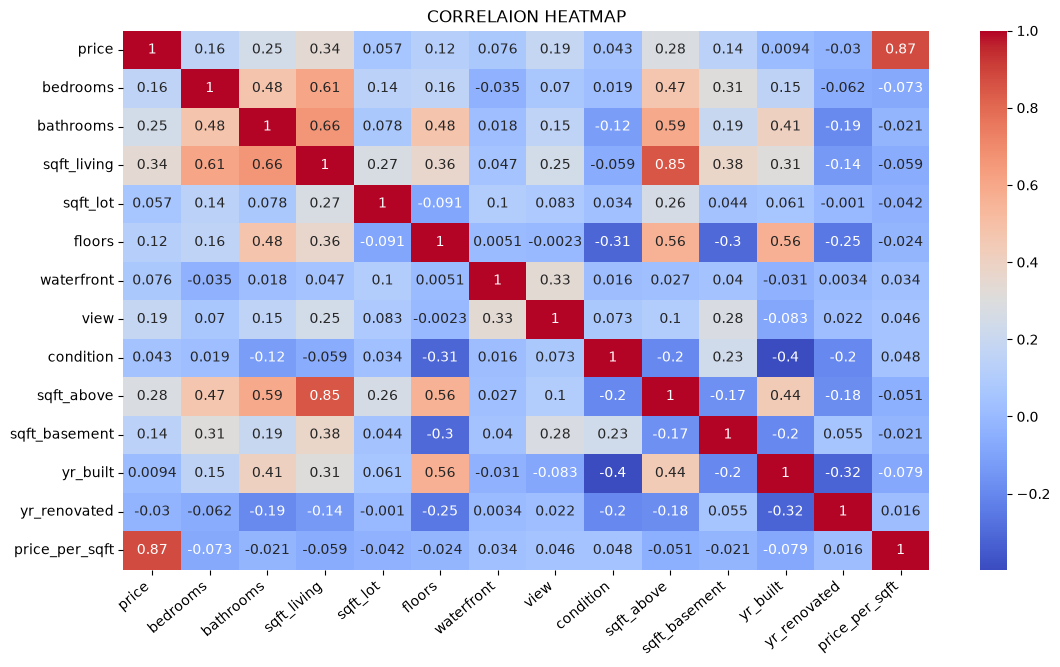

In [13]:
corr = df.corr(numeric_only = True)

plt.figure(figsize = (13,7))
sns.heatmap(corr , annot = True , cmap = 'coolwarm')
plt.title('CORRELAION HEATMAP')
plt.xticks(rotation = 40 , ha = 'right')
plt.show()

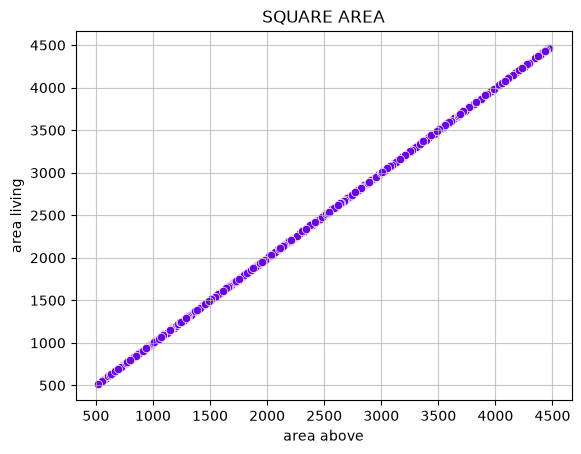

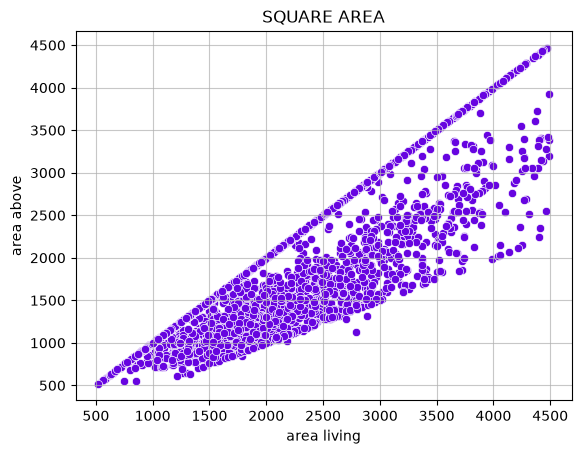

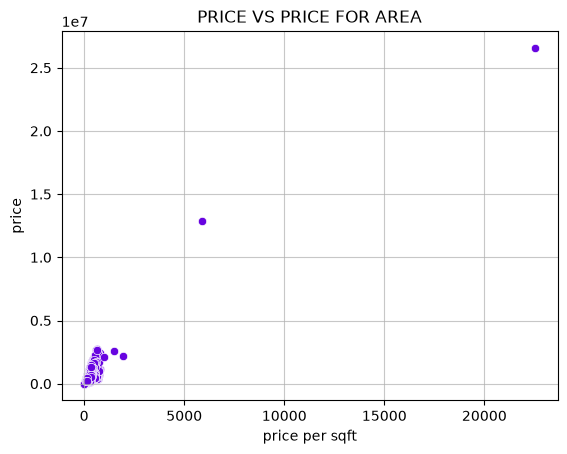

In [14]:
sns.scatterplot(data = df , x = 'sqft_above' , y = 'sqft_above',color = '#6704e0')
plt.title('SQUARE AREA')
plt.ylabel('area living')
plt.xlabel('area above')
plt.grid(True , alpha = 0.7)
plt.show()

sns.scatterplot(data = df , x = 'sqft_living' , y = 'sqft_above',color = '#6704e0')
plt.title('SQUARE AREA')
plt.xlabel('area living')
plt.ylabel('area above')
plt.grid(True , alpha = 0.7)
plt.show()

sns.scatterplot(data = df , x = 'price_per_sqft' , y = 'price',color = '#6704e0')
plt.title('PRICE VS PRICE FOR AREA')
plt.xlabel('price per sqft')
plt.ylabel('price')
plt.grid(True , alpha = 0.7)
plt.show()

# ML MODEL

In [15]:
# Importing important models 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [16]:
print(df['price_per_sqft'].describe())

count     4290.000000
mean       266.127413
std        368.666982
min          0.000000
25%        180.027500
50%        244.905000
75%        314.770000
max      22533.900000
Name: price_per_sqft, dtype: float64


In [17]:

# Features
x = df[
    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        "waterfront",
        "view",
        "condition",
        "sqft_basement"
    ]
]

# Target
y = df["price"]

# Train / test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
y_train_log = np.log1p(y_train)
# Fit model on y_train_log, then use np.expm1(y_pred) to get actual dollar predictions back

# Model
model = LinearRegression()

# Fit on log-transformed price
y_train_log = np.log1p(y_train)
model.fit(x_train, y_train_log)

# Convert predictions back to dollar amounts before scoring
y_pred_log = model.predict(x_test)
y_pred = np.expm1(y_pred_log)
# Evaluation
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mse)
print("ROOT MEAN SQUARED ERROR:", np.sqrt(mse))

R2: 0.05147565183629965
Mean Absolute Error: 191941.0285939379
Mean Squared Error: 244787545656.12616
ROOT MEAN SQUARED ERROR: 494760.08898872003


In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Clean zero prices
df_clean = df[df['price'] > 0].copy()

# 2. Features (including city) & Target
features = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", 
            "waterfront", "view", "condition", "sqft_basement", "city"]

x = pd.get_dummies(df_clean[features], columns=['city'], drop_first=True)
y = df_clean["price"]

# 3. Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 4. Fit Model on Log-Transformed Target
y_train_log = np.log1p(y_train)
model = LinearRegression()
model.fit(x_train, y_train_log)

# 5. Predict and Reverse Log
y_pred_log = model.predict(x_test)
y_pred = np.expm1(y_pred_log)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", np.sqrt(mse)) 

R2 Score: 0.6930939152766741
Mean Absolute Error: 103909.13372840786
Mean Squared Error: 27054177875.279125
Root Mean Squared Error: 164481.5426583759


# House Price Prediction Project - Summary & Final Verdict

---

### **Project Overview**

* **Goal**: Predict Washington State house prices using property features (e.g., square footage, bedrooms, bathrooms, location).
* **Core Dataset**: 4,600 historical property sales records.
* **Key Challenge Handled**: High right-skewness in prices and strong geographic pricing drivers.

---

### **Performance Comparison**

* **Initial Baseline Model**
* $R^2$ Score: **0.128**
* Mean Absolute Error (MAE): **$170,473.58**
* Root Mean Squared Error (RMSE): **$474,338.87**


* **Final Refined Model**
* **$R^2$ Score**: **0.693** *(Up by +441%)*
* **Mean Absolute Error (MAE)**: **$103,909.13** *(Reduced by ~$66.5k)*
* **Root Mean Squared Error (RMSE)**: **$164,481.54** *(Reduced by ~$309.8k)*



---

### **Key Technical Improvements Made**

1. **Target Log Transformation**
* Applied `np.log1p()` on target price to scale multi-million dollar luxury outliers, preventing massive squared error penalties.
* Reversed back to dollar predictions using `np.expm1()`.


2. **Categorical Location Feature Integration**
* Encoded categorical `city` variable using `pd.get_dummies()`, providing essential spatial signals to the linear model.


3. **Data Cleaning & Filtering**
* Removed erroneous **$0** listing prices from the dataset before training.



---

### **Future Iterations & Recommendations**

* **Use `statezip**`: Replace `city` with zip codes to capture block-level neighborhood values.
* **Feature Engineering**: Compute `house_age = 2026 - yr_built` to give a direct age-depreciation metric.
* **Tree-Based Models**: Upgrade to `RandomForestRegressor` or `HistGradientBoostingRegressor` to capture non-linear relationships and interactions automatically.

In [19]:
import joblib

# Save the trained model to disk
joblib.dump(model, 'house_model.pkl')

['house_model.pkl']

In [ ]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
import os

app = Flask(__name__)

# Load the saved linear regression model
model = joblib.load('house_model.pkl')

@app.route('/')
def home():
    return jsonify({"status": "API is running!"})

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        
        # Convert incoming JSON into a DataFrame
        input_df = pd.DataFrame([data])
        
        # Make log-scale prediction and reverse with expm1
        log_pred = model.predict(input_df)
        prediction = np.expm1(log_pred)[0]
        
        return jsonify({'predicted_price': round(float(prediction), 2)})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # Render assigns dynamic PORT environment variables
    port = int(os.environ.get('PORT', 5000))
    app.run(host='0.0.0.0', port=port)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.2:5000
Press CTRL+C to quit


In [ ]:
# 1. Generate app.py
app_code = """from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
import os

app = Flask(__name__)

model = joblib.load('house_model.pkl')

@app.route('/')
def home():
    return jsonify({"status": "API is running!"})

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        input_df = pd.DataFrame([data])
        log_pred = model.predict(input_df)
        prediction = np.expm1(log_pred)[0]
        return jsonify({'predicted_price': round(float(prediction), 2)})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    port = int(os.environ.get('PORT', 5000))
    app.run(host='0.0.0.0', port=port)
"""

with open("app.py", "w") as f:
    f.write(app_code)

# 2. Generate requirements.txt
req_code = """flask
gunicorn
scikit-learn
pandas
numpy
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(req_code)

# 3. Generate Procfile
procfile_code = "web: gunicorn app:app"

with open("Procfile", "w") as f:
    f.write(procfile_code)

print("All deployment files created successfully!")